# Notebook 4 — N-grams and Phrase Evolution

Words are limited. Pop music's hooks live in phrases. This notebook asks:

1. What are the most common 2-, 3-, and 4-grams overall? Per decade?
2. Which phrases **suddenly emerged** in pop history? Which **died**?
3. How does the prevalence of canonical phrases ("I love you", "baby baby") shift?
4. Which decades had the most homogeneous phrase usage (everyone said the same things) vs the most diverse?

We use both raw n-gram counts and TF-IDF (term frequency × inverse document frequency) to find phrases that are *characteristic* of a decade, not just common everywhere.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (13, 5)

PROCESSED_DIR = Path.cwd().parent / "data" / "processed"
df = pd.read_parquet(PROCESSED_DIR / "songs_preprocessed.parquet")
df_en = df[df["language"] == "en"].copy()
print(f"English songs: {len(df_en):,}")

English songs: 6,538


## Build n-gram extractors

We extract n-grams from the tokenized lyrics (lowercased, alphabetic). We deliberately keep stopwords — for phrase analysis, "I love you" is the whole point, and stripping "I" and "you" would destroy it.

Apostrophe-containing tokens are preserved (`don't`, `you're`).

In [2]:
def ngrams(tokens: list[str], n: int) -> list[str]:
    """Return space-joined n-grams from a token list."""
    if len(tokens) < n:
        return []
    return [" ".join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

# Add n-gram columns
for n in [2, 3, 4]:
    df_en[f"ngrams_{n}"] = df_en["tokens"].apply(lambda toks: ngrams(toks, n))

# Sanity check
print("Sample 3-grams from 'Espresso':")
sample = df_en[df_en["title"] == "Espresso"].iloc[0] if (df_en["title"] == "Espresso").any() else df_en.iloc[0]
print(sample["ngrams_3"][:10])

Sample 3-grams from 'Espresso':
["now he's thinkin", "he's thinkin bout", 'thinkin bout me', 'bout me every', 'me every night', 'every night oh', 'night oh is', 'oh is it', 'is it that', 'it that sweet']


## Most common n-grams overall

What are pop music's all-time most common phrases? This is the canonical pop dictionary.

In [3]:
def collect_ngrams(token_lists):
    """Aggregate n-grams across a column of n-gram lists."""
    counter = Counter()
    for grams in token_lists:
        counter.update(grams)
    return counter

# Overall top 20 for each n
for n in [2, 3, 4]:
    counter = collect_ngrams(df_en[f"ngrams_{n}"])
    print(f"\nTop 25 {n}-grams overall:")
    for gram, count in counter.most_common(25):
        print(f"  {count:6d}  {gram}")


Top 25 2-grams overall:
   10003  oh oh
    8385  in the
    5552  and i
    5363  yeah yeah
    4936  you know
    4849  i don't
    4758  i know
    4508  na na
    4309  on the
    4147  la la
    4059  ooh ooh
    3879  if you
    3784  to the
    3425  love you
    3299  i can't
    3138  that i
    3115  i love
    3108  to me
    3095  i can
    3065  in my
    3064  i got
    3053  the way
    3008  come on
    2947  to be
    2939  like a

Top 25 3-grams overall:
    6419  oh oh oh
    3852  na na na
    3428  la la la
    2732  yeah yeah yeah
    2537  ooh ooh ooh
    1635  i love you
    1441  da da da
    1439  no no no
    1033  do do do
     996  i don't know
     994  ah ah ah
     911  the way you
     872  i don't wanna
     815  i want you
     800  doo doo doo
     789  you know i
     677  i want to
     669  i know you
     638  i need you
     637  in love with
     621  you and i
     616  hey hey hey
     597  you love me
     579  you know that
     570  i kno

## Per-decade n-gram analysis

For each decade, we find the most common n-grams. But common n-grams everywhere (like "I love you") aren't interesting. We use **TF-IDF** to find phrases that are *characteristic* of a specific decade.

Treat each decade as a "document", with its n-grams aggregated. A phrase has high TF-IDF for a decade if it's common in that decade and rare in others.

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Build decade-level documents from 3-grams
decade_docs = {}
for decade, group in df_en.groupby("decade"):
    # Concatenate all 3-grams from songs in this decade
    all_grams = []
    for grams in group["ngrams_3"]:
        all_grams.extend(grams)
    decade_docs[decade] = " | ".join(all_grams)  # joiner is unique so vectorizer won't accidentally split

decades = sorted(decade_docs.keys())
# Drop 1940s — small sample, results will be unreliable
decades = [d for d in decades if d >= 1950]

# Use the n-grams directly as tokens. We pass tokenizer=str.split since they're already extracted.
vectorizer = TfidfVectorizer(
    tokenizer=lambda s: s.split(" | "),
    lowercase=False,
    min_df=2,        # phrase must appear in at least 2 decades to qualify
    sublinear_tf=True,
    token_pattern=None,
)
tfidf = vectorizer.fit_transform([decade_docs[d] for d in decades])
features = np.array(vectorizer.get_feature_names_out())

# Top 15 most distinctive 3-grams per decade
print("Most CHARACTERISTIC 3-grams per decade (by TF-IDF):\n")
for i, decade in enumerate(decades):
    row = tfidf[i].toarray().flatten()
    top_idx = row.argsort()[::-1][:15]
    print(f"--- {decade}s ---")
    for idx in top_idx:
        print(f"  {row[idx]:.4f}  {features[idx]}")
    print()

Most CHARACTERISTIC 3-grams per decade (by TF-IDF):

--- 1950s ---
  0.0326  in his hands
  0.0321  it be let
  0.0318  turn me loose
  0.0308  me say day
  0.0304  day o day
  0.0301  daylight come and
  0.0301  sugar in the
  0.0293  lolli lolli lolli
  0.0289  over the bridge
  0.0289  tell him no
  0.0289  dream dream dream
  0.0284  wake up little
  0.0284  up little susie
  0.0284  bop a lula
  0.0284  be bop a

--- 1960s ---
  0.0196  ta ta ta
  0.0189  doo ron ron
  0.0189  da doo ron
  0.0188  can't sit down
  0.0188  help me rhonda
  0.0188  bar bar bar
  0.0188  you can't sit
  0.0187  show you where
  0.0185  me rhonda help
  0.0184  ee ee ee
  0.0177  dit dit dit
  0.0177  a well a
  0.0176  sit down you
  0.0170  i'm black and
  0.0170  and i'm proud

--- 1970s ---
  0.0182  du du du
  0.0176  gonna walk away
  0.0172  doo ron ron
  0.0171  da doo ron
  0.0170  to you good
  0.0170  you good to
  0.0165  can say goodbye
  0.0165  duh duh duh
  0.0164  never can say
  0.01

## Phrase emergence and death

Find phrases that first appeared in pop charts in a specific decade and persisted, vs. phrases that died.

A phrase "emerged" in decade X if it was nearly absent before X and common from X onward. A phrase "died" in decade X if it was common before and rare after.

In [5]:
# Per-decade phrase frequency (occurrences per million 3-grams)
decade_freq = {}
decade_totals = {}
for decade in decades:
    counter = collect_ngrams(df_en[df_en["decade"] == decade]["ngrams_3"])
    total = sum(counter.values())
    decade_totals[decade] = total
    decade_freq[decade] = {gram: count / total * 1e6 for gram, count in counter.items()}

# Build a long DataFrame of phrase frequencies per decade
all_phrases = set()
for d in decades:
    all_phrases.update(decade_freq[d].keys())

# Restrict to phrases that ever exceeded 100 ppm in any decade — focus on real hits
hot_phrases = {p for p in all_phrases 
               if any(decade_freq[d].get(p, 0) >= 100 for d in decades)}

phrase_matrix = pd.DataFrame(
    {p: [decade_freq[d].get(p, 0) for d in decades] for p in hot_phrases},
    index=decades,
).T  # rows = phrases, columns = decades

print(f"Phrases that exceeded 100 ppm in at least one decade: {len(phrase_matrix)}")

# Emergence: phrase had ~0 frequency in earliest decade(s), substantial in latest
def find_emergent(matrix, early=2, late=2, early_max=20, late_min=200):
    """Phrases nearly absent in `early` earliest decades, prevalent in `late` latest."""
    early_cols = matrix.columns[:early]
    late_cols = matrix.columns[-late:]
    early_score = matrix[early_cols].max(axis=1)
    late_score = matrix[late_cols].max(axis=1)
    mask = (early_score <= early_max) & (late_score >= late_min)
    return matrix[mask].assign(early=early_score, late=late_score).sort_values("late", ascending=False)

emergent = find_emergent(phrase_matrix)
print(f"\nEmergent phrases (rare in earliest decades, common in 2010s/2020s):")
print(emergent[["early", "late"] + list(decades)].head(20).round(0))

Phrases that exceeded 100 ppm in at least one decade: 2473

Emergent phrases (rare in earliest decades, common in 2010s/2020s):
                    early   late  1950  1960   1970  1980  1990  2000   2010  \
low low low           0.0  669.0   0.0   0.0    8.0  10.0   2.0  95.0  669.0   
boaw boaw boaw        0.0  565.0   0.0   0.0    0.0   0.0   0.0   0.0    0.0   
bam bam bam           0.0  456.0   0.0   0.0    0.0   0.0   2.0   0.0    0.0   
doh doh doh           0.0  413.0   0.0   0.0    0.0   0.0   0.0   0.0  413.0   
lo lo lo              0.0  399.0   0.0   0.0  132.0   0.0   5.0   0.0  399.0   
up up up              0.0  307.0   0.0   0.0    0.0   0.0   0.0   0.0  307.0   
n fe n                0.0  299.0   0.0   0.0    0.0   0.0   0.0   0.0    0.0   
fe n fe               0.0  299.0   0.0   0.0    0.0   0.0   0.0   0.0    0.0   
your hands up         0.0  263.0   0.0   0.0    4.0   0.0  24.0  83.0  263.0   
up all night          0.0  245.0   0.0   0.0    4.0  26.0  12.0   4.0  2

In [6]:
# Same but inverted: phrases that died
def find_dying(matrix, early=2, late=2, early_min=200, late_max=20):
    early_cols = matrix.columns[:early]
    late_cols = matrix.columns[-late:]
    early_score = matrix[early_cols].max(axis=1)
    late_score = matrix[late_cols].max(axis=1)
    mask = (early_score >= early_min) & (late_score <= late_max)
    return matrix[mask].assign(early=early_score, late=late_score).sort_values("early", ascending=False)

dying = find_dying(phrase_matrix)
print(f"Dying phrases (common in 1950s/1960s, rare in 2010s/2020s):")
print(dying[["early", "late"] + list(decades)].head(20).round(0))

Dying phrases (common in 1950s/1960s, rare in 2010s/2020s):
                    early  late   1950   1960   1970   1980  1990   2000  \
dat un dat          901.0   0.0  901.0    0.0    0.0    0.0   0.0    0.0   
tzena tzena tzena   765.0   0.0  765.0    0.0    0.0    0.0   0.0    0.0   
love you so         748.0  18.0  748.0  188.0  144.0  121.0  67.0   32.0   
lee mr lee          697.0   0.0  697.0    0.0    0.0    0.0   0.0    0.0   
mr lee mr           697.0   0.0  697.0    0.0    0.0    0.0   0.0    0.0   
go stagger lee      697.0   0.0  697.0    0.0    0.0    0.0   0.0    0.0   
bah bah bah         680.0   7.0  680.0    0.0    0.0    0.0  34.0   32.0   
um um um            671.0   0.0    0.0  671.0    0.0    0.0   0.0    0.0   
over and over       646.0  16.0  646.0   97.0   39.0   89.0  10.0  109.0   
un dat un           612.0   0.0  612.0    0.0    0.0    0.0   0.0    0.0   
stagger lee go      493.0   0.0  493.0    0.0    0.0    0.0   0.0    0.0   
lee go stagger      476.0   

## Visualize a few interesting trajectories

Pick a handful of phrases (canonical, emergent, dying) and plot their trajectories.

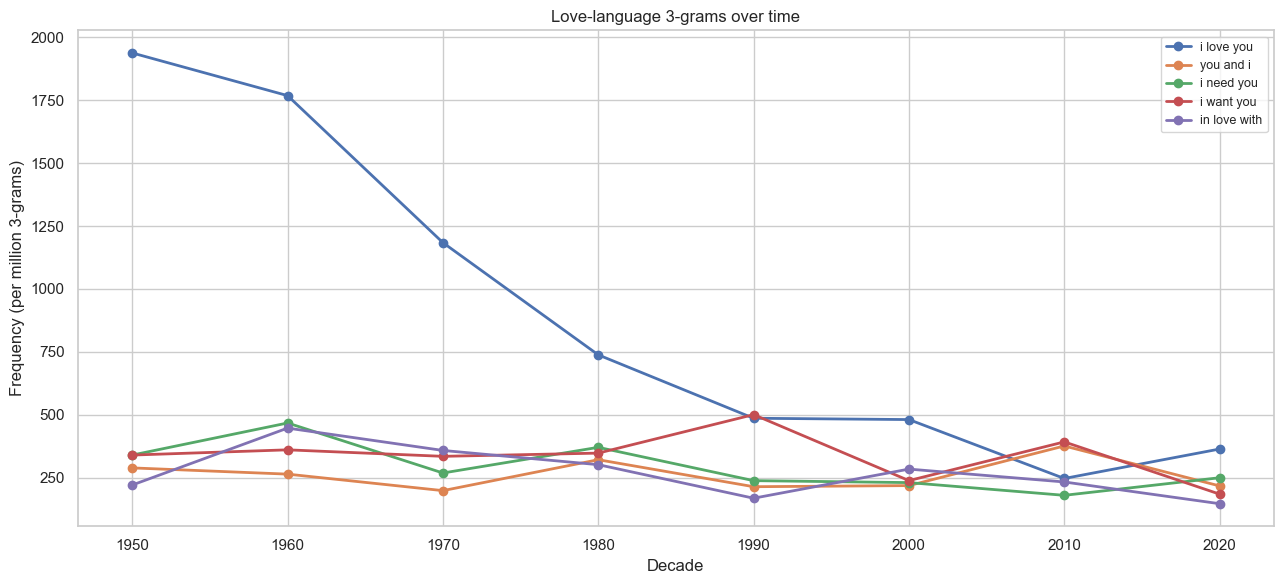

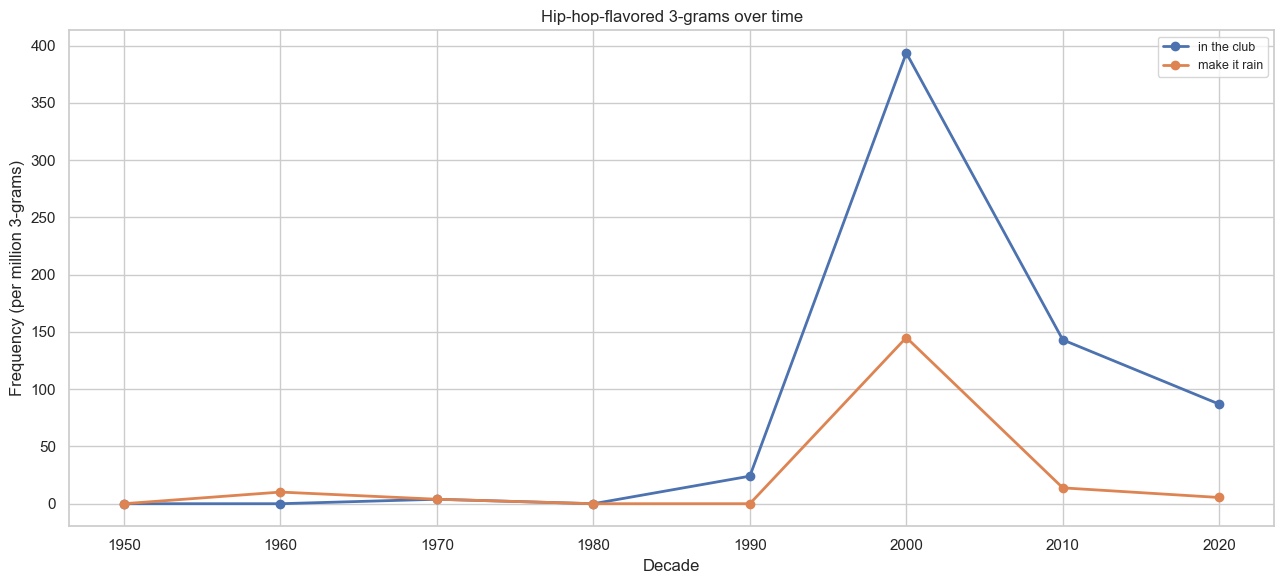

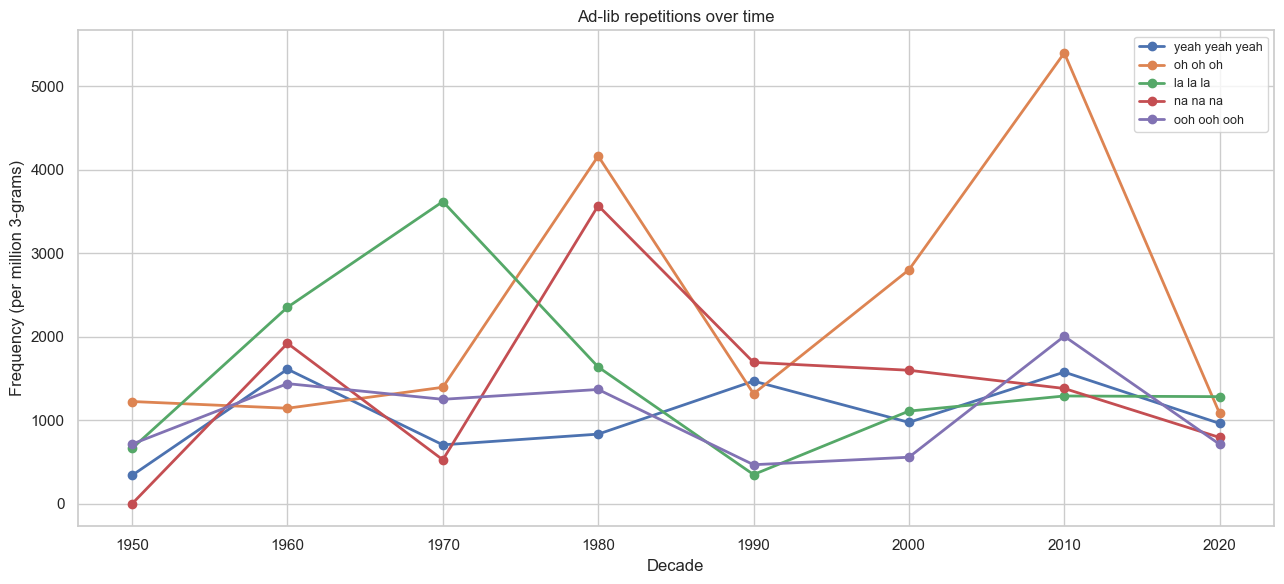

In [7]:
def plot_phrase_trajectories(phrases, title):
    fig, ax = plt.subplots(figsize=(13, 6))
    for phrase in phrases:
        if phrase in phrase_matrix.index:
            ax.plot(decades, phrase_matrix.loc[phrase], "o-", label=phrase, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel("Decade"); ax.set_ylabel("Frequency (per million 3-grams)")
    ax.legend(loc="best", fontsize=9)
    plt.tight_layout(); plt.show()

# Canonical / love
plot_phrase_trajectories(
    ["i love you", "you and i", "i need you", "i want you", "in love with"],
    "Love-language 3-grams over time")

# Hip-hop emergence
plot_phrase_trajectories(
    ["in the club", "all my niggas", "on the beat", "rest in peace", "make it rain"],
    "Hip-hop-flavored 3-grams over time")

# Filler/ad-libs
plot_phrase_trajectories(
    ["yeah yeah yeah", "oh oh oh", "la la la", "na na na", "ooh ooh ooh"],
    "Ad-lib repetitions over time")

## Findings summary

Fill in after running:

- Most common 3-gram of all time: ???
- Decade with most distinctive vocabulary: ???
- Most striking emergent phrase: ???
- Most striking dying phrase: ???
- Most stable phrase (similar frequency every decade): ???

## Cleaner decade signatures: phrases that appeared in ≥5 distinct songs

The TF-IDF results above are noisy because single hit songs dominate the rankings ("lolli lolli lolli", "boaw boaw boaw"). Real decade-defining patterns should appear across many different songs.

Filter to phrases used in at least 5 different songs within the decade.

In [8]:
# Phrase → set of song_ids it appeared in, per decade
from collections import defaultdict

decade_phrase_songs = defaultdict(lambda: defaultdict(set))
for _, row in df_en.iterrows():
    for gram in set(row["ngrams_3"]):  # set: count each phrase once per song
        decade_phrase_songs[row["decade"]][gram].add(row["id"])

# Build phrase → song count, per decade
MIN_SONGS = 5
phrase_song_counts = {
    d: {p: len(songs) for p, songs in pdict.items() if len(songs) >= MIN_SONGS}
    for d, pdict in decade_phrase_songs.items()
}

# Re-do TF-IDF but only on phrases appearing in ≥5 songs in their decade
# A phrase is eligible if it hit the floor in any decade
eligible_phrases = set()
for d in decades:
    eligible_phrases.update(phrase_song_counts.get(d, {}).keys())

print(f"Eligible phrases (≥{MIN_SONGS} songs in some decade): {len(eligible_phrases)}")

# Per-decade frequency, restricted to eligible
def relative_freq(decade, phrase):
    pop = phrase_song_counts.get(decade, {}).get(phrase, 0)
    n_songs = (df_en["decade"] == decade).sum()
    return pop / n_songs if n_songs else 0

# For each decade, find phrases that are MUCH more common in this decade
# than in any other (a ratio-based "characteristicness")
print("\nMost CHARACTERISTIC 3-grams per decade (≥5 songs, ratio-based):\n")
for decade in decades:
    scores = []
    for p in phrase_song_counts.get(decade, {}):
        this = relative_freq(decade, p)
        other_max = max((relative_freq(d2, p) for d2 in decades if d2 != decade),
                        default=0)
        # Skip phrases that aren't actually more common in this decade
        if this < 1.5 * other_max and other_max > 0:
            continue
        scores.append((this, p, phrase_song_counts[decade][p]))
    scores.sort(reverse=True)
    print(f"--- {decade}s ---")
    for rate, phrase, n_songs in scores[:12]:
        print(f"  {rate*100:5.1f}% of songs  ({n_songs} songs)  {phrase}")
    print()

Eligible phrases (≥5 songs in some decade): 7300

Most CHARACTERISTIC 3-grams per decade (≥5 songs, ratio-based):

--- 1950s ---
    4.4% of songs  (14 songs)  love you so
    2.2% of songs  (7 songs)  me oh my
    1.9% of songs  (6 songs)  you kiss me
    1.9% of songs  (6 songs)  in the moonlight
    1.6% of songs  (5 songs)  your sweet lips
    1.6% of songs  (5 songs)  you will find
    1.6% of songs  (5 songs)  when the sun
    1.6% of songs  (5 songs)  when i feel
    1.6% of songs  (5 songs)  wait and see
    1.6% of songs  (5 songs)  the magic of
    1.6% of songs  (5 songs)  so don't you
    1.6% of songs  (5 songs)  oh my love

--- 1960s ---
    1.6% of songs  (15 songs)  down the street
    1.4% of songs  (13 songs)  you baby baby
    1.3% of songs  (12 songs)  end of time
    1.2% of songs  (11 songs)  you can make
    1.2% of songs  (11 songs)  the name of
    1.2% of songs  (11 songs)  each time i
    1.1% of songs  (10 songs)  uh huh huh
    1.1% of songs  (10 songs)  to